# Standard Logistic Regression - Cancer Risk Dataset

This notebook trains a standard (non-private) Logistic Regression classifier on the Cancer Risk Prediction dataset (1500 samples, 8 features) to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import os
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
# Load preprocessed data
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']
bounds = data['bounds']
scaler = data['scaler']

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)
data_norm = 1.0

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Training data shape: (1200, 8)
Test data shape: (300, 8)
Number of features: 8

Features: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']


## 3. Train Standard Logistic Regression Model

In [3]:
# Initialize Logistic Regression Classifier
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

print("Training Standard Logistic Regression...")
_t0 = time.perf_counter()
lr_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = lr_model.predict(X_train)
print("Training complete!")

Training Standard Logistic Regression...
Training complete!


In [4]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(lr_model, 'output/model/std_lr_model.pkl')

Model successfully exported to output/model/std_lr_model.pkl


## 4. Make Predictions

In [5]:
# Predictions on test set
y_pred = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")
print(f"Data of prediction probability", y_pred_proba[:5, 1])

Predictions shape: (300,)
Prediction probabilities shape: (300, 2)
Data of prediction probability [0.12501082 0.33961079 0.91399144 0.10527911 0.83045422]


## 5. Model Evaluation

In [6]:
# Calculate metrics
extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=lr_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("=" * 60)
print("STANDARD LOGISTIC REGRESSION - PERFORMANCE METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("=" * 60)

STANDARD LOGISTIC REGRESSION - PERFORMANCE METRICS
Accuracy:  0.8500
F1-Score:  0.7926
Precision: 0.8113
Recall:    0.7748


## 6. Confusion Matrix

Rearranged for medical interpretation:
- **Top-left (TP):** Correctly identified cancer cases
- **Top-right (FN):** Missed cancer cases (most dangerous in medical context)
- **Bottom-left (FP):** False alarms
- **Bottom-right (TN):** Correctly identified non-cancer cases

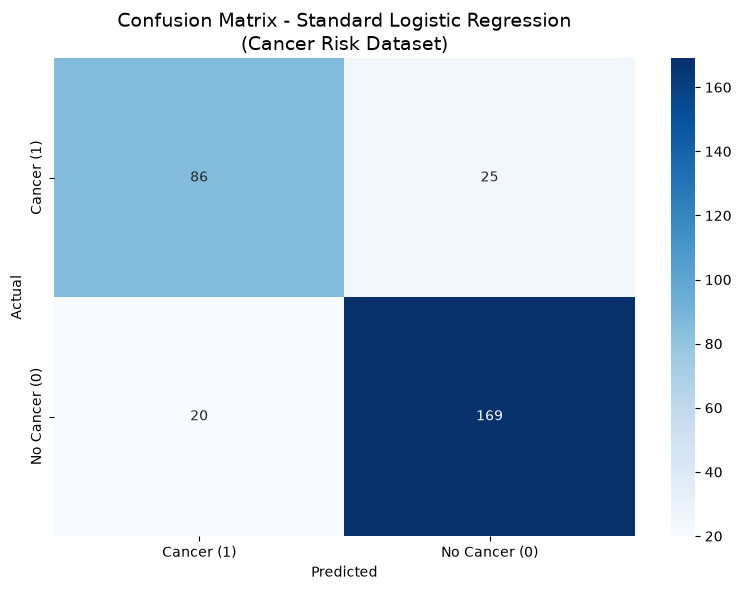


Confusion Matrix (Medical Interpretation):
  [  86 (TP)    25 (FN)]
  [  20 (FP)   169 (TN)]

True Positives (TP): 86 - Correctly identified cancer
False Negatives (FN): 25 - Missed cancer cases
False Positives (FP): 20 - False alarms
True Negatives (TN): 169 - Correctly identified non-cancer


In [7]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Rearrange for medical interpretation (TP, FN / FP, TN)
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancer (1)', 'No Cancer (0)'],
            yticklabels=['Cancer (1)', 'No Cancer (0)'])
plt.title('Confusion Matrix - Standard Logistic Regression\n(Cancer Risk Dataset)', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix (Medical Interpretation):")
print(f"  [{TP:4d} (TP)  {FN:4d} (FN)]")
print(f"  [{FP:4d} (FP)  {TN:4d} (TN)]")
print(f"\nTrue Positives (TP): {TP} - Correctly identified cancer")
print(f"False Negatives (FN): {FN} - Missed cancer cases")
print(f"False Positives (FP): {FP} - False alarms")
print(f"True Negatives (TN): {TN} - Correctly identified non-cancer")

## 7. Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred,
                          target_names=['No Cancer (0)', 'Cancer (1)']))

Classification Report:
               precision    recall  f1-score   support

No Cancer (0)       0.87      0.89      0.88       189
   Cancer (1)       0.81      0.77      0.79       111

     accuracy                           0.85       300
    macro avg       0.84      0.83      0.84       300
 weighted avg       0.85      0.85      0.85       300



## 8. Model Coefficients

Feature Importance (by coefficient magnitude):
         feature  coefficient
   CancerHistory     3.828046
   AlcoholIntake     2.926286
     GeneticRisk     2.866662
             Age     2.707469
             BMI     2.504542
PhysicalActivity    -2.102098
          Gender     1.955760
         Smoking     1.865678


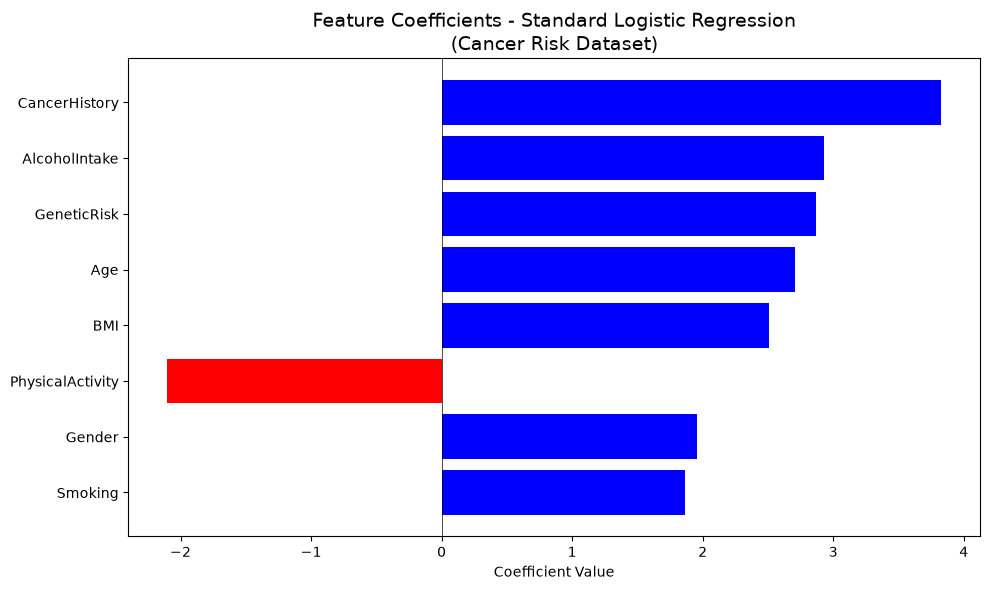


Intercept: 1.3954


In [9]:
# Get model coefficients
coefficients = lr_model.coef_[0]
coefficient_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values('abs_coefficient', ascending=False)

print("Feature Importance (by coefficient magnitude):")
print(coefficient_df[['feature', 'coefficient']].to_string(index=False))

# Visualize feature coefficients
plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'blue' for c in coefficient_df['coefficient']]
plt.barh(range(len(coefficient_df)), coefficient_df['coefficient'], color=colors)
plt.yticks(range(len(coefficient_df)), coefficient_df['feature'])
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients - Standard Logistic Regression\n(Cancer Risk Dataset)', fontsize=14)
plt.gca().invert_yaxis()
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\nIntercept: {lr_model.intercept_[0]:.4f}")

## 9. Save Baseline Results

In [10]:
# Create output directory if it does not exist
os.makedirs('output', exist_ok=True)

# Save baseline metrics to CSV
baseline_results = pd.DataFrame({
    'model': ['Standard_LR'],
    'accuracy': [accuracy],
    'f1_score': [f1],
    'precision': [precision],
    'recall': [recall]
})

baseline_results.to_csv('./output/baseline_results.csv', index=False)
print("Baseline results saved to './output/baseline_results.csv'")

# Save detailed report to JSON
report = {
    'model_type': 'Standard Logistic Regression',
    'dataset': 'Cancer Risk Prediction',
    'n_samples': X_train.shape[0] + X_test.shape[0],
    'n_features': X_train.shape[1],
    'feature_names': feature_names,
    'parameters': {
        'max_iter': 1000,
        'random_state': 42,
        'solver': 'lbfgs'
    },
    'metrics': {
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    },
    'confusion_matrix': custom_cm.tolist(),
    'coefficients': coefficient_df[['feature', 'coefficient']].to_dict('records'),
    'intercept': float(lr_model.intercept_[0])
}
report.update(extra.means())

with open('./output/std_lr_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Detailed report saved to './output/std_lr_report.json'")

print("Added metrics:")
print(extra.describe())

Baseline results saved to './output/baseline_results.csv'
Detailed report saved to './output/std_lr_report.json'
Added metrics:
  Train Acc:      0.8592 ± 0.0000
  Balanced Acc:   0.8345 ± 0.0000
  AUROC:          0.9226 ± 0.0000
  Train Time (s): 0.0023 ± 0.0000


## 10. Summary

In [11]:
print("\n" + "=" * 60)
print("BASELINE MODEL SUMMARY")
print("=" * 60)
print(f"Model: Standard Logistic Regression")
print(f"Dataset: Cancer Risk Prediction ({X_train.shape[0]:,} train, {X_test.shape[0]:,} test)")
print(f"Features: {len(feature_names)} ({', '.join(feature_names)})")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"\nBaseline established for DP comparison")
print("=" * 60)


BASELINE MODEL SUMMARY
Model: Standard Logistic Regression
Dataset: Cancer Risk Prediction (1,200 train, 300 test)
Features: 8 (Age, Gender, BMI, Smoking, GeneticRisk, PhysicalActivity, AlcoholIntake, CancerHistory)

Performance Metrics:
  Accuracy:  0.8500
  F1-Score:  0.7926
  Precision: 0.8113
  Recall:    0.7748

Baseline established for DP comparison
